In [1]:
# === XGBoost + RandomizedSearchCV (fokus: Recall Churn) ===
import pandas as pd
import numpy as np
from scipy.stats import randint, uniform, loguniform
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, precision_recall_curve)

In [2]:
X_train = pd.read_csv('X_train_ohe_int.csv')
X_test = pd.read_csv('X_test_ohe_int.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

In [3]:
# 0) Hitung rasio imbalance utk acuan scale_pos_weight
pos = np.sum(y_train)
neg = len(y_train) - pos
spw_base = neg / pos  # aturan praktis XGBoost

In [4]:
# 1) Estimator dasar (param lain dicari lewat random search)
xgb = XGBClassifier(
    booster="gbtree",
    tree_method="hist",        # cepat untuk tabular
    eval_metric="logloss",     # hindari warning & konsisten
    n_jobs=-1,
    random_state=42
)

In [5]:
# 2) Ruang pencarian hyperparameter
#    Catatan efek:
#    - learning_rate kecil + n_estimators besar → model halus (umum di boosting)
#    - max_depth & min_child_weight → kontrol kompleksitas tree
#    - subsample & colsample_bytree → randomization (kurangi overfit)
#    - gamma, reg_alpha, reg_lambda → regularisasi tambahan
#    - scale_pos_weight → penting utk imbalance (sekitar rasio neg/pos)
param_dist = {
    "n_estimators": randint(200, 1001),           # 200..1000
    "learning_rate": loguniform(1e-3, 3e-1),      # ~0.001..0.3
    "max_depth": randint(3, 11),                  # 3..10
    "min_child_weight": randint(1, 11),           # 1..10
    "subsample": uniform(0.5, 0.5),               # 0.5..1.0
    "colsample_bytree": uniform(0.5, 0.5),        # 0.5..1.0
    "gamma": loguniform(1e-8, 1e0),               # 1e-8..1
    "reg_alpha": loguniform(1e-8, 1e0),           # L1
    "reg_lambda": loguniform(1e-3, 1e2),          # L2
    "scale_pos_weight": [0.5*spw_base, spw_base, 1.5*spw_base, 2*spw_base]
}

In [6]:
# 3) CV stratified + multi-metric (refit = recall)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "accuracy": "accuracy"
}

In [7]:

rs_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=80,                     # 60–150 umumnya oke; sesuaikan waktu
    scoring=scoring,
    refit="recall",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)


In [8]:
# 4) Jalankan pencarian
rs_xgb.fit(X_train, y_train.ravel())

print("Best params (berdasarkan Recall CV):")
print(rs_xgb.best_params_)
best_idx = rs_xgb.best_index_
print("\nSkor CV rata-rata pada best index:")
for k in scoring:
    print(f"{k:>9}: {rs_xgb.cv_results_[f'mean_test_{k}'][best_idx]:.4f}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params (berdasarkan Recall CV):
{'colsample_bytree': np.float64(0.8005575058716043), 'gamma': np.float64(0.004619347374377372), 'learning_rate': np.float64(0.001124579825911934), 'max_depth': 4, 'min_child_weight': 8, 'n_estimators': 691, 'reg_alpha': np.float64(0.3224197761544067), 'reg_lambda': np.float64(0.0010090061869151559), 'scale_pos_weight': np.float64(5.525083612040134), 'subsample': np.float64(0.5917022549267169)}

Skor CV rata-rata pada best index:
   recall: 0.9538
precision: 0.3909
       f1: 0.5545
  roc_auc: 0.8421
 accuracy: 0.5925


In [9]:
# 5) Evaluasi di test set (threshold default)
best_xgb = rs_xgb.best_estimator_
y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred, target_names=["No Churn","Churn"]))
print(f"ROC-AUC (Test): {roc_auc_score(y_test, y_proba):.4f}")


Confusion Matrix (Test):
[[446 587]
 [ 19 355]]

Classification Report (Test):
              precision    recall  f1-score   support

    No Churn       0.96      0.43      0.60      1033
       Churn       0.38      0.95      0.54       374

    accuracy                           0.57      1407
   macro avg       0.67      0.69      0.57      1407
weighted avg       0.80      0.57      0.58      1407

ROC-AUC (Test): 0.8276


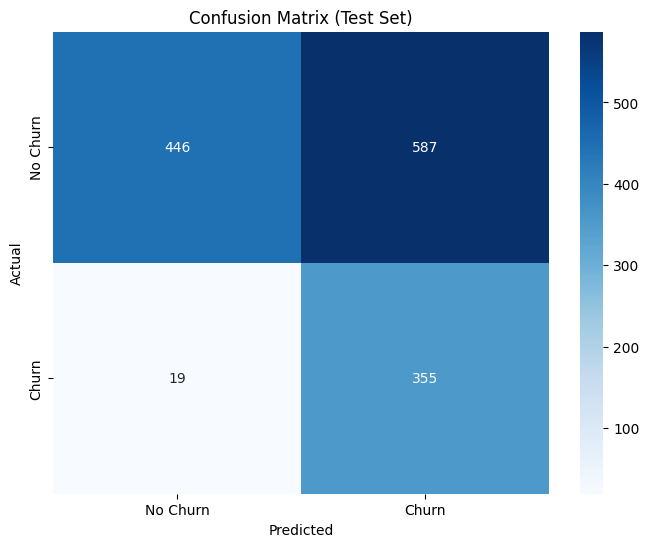

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])

plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

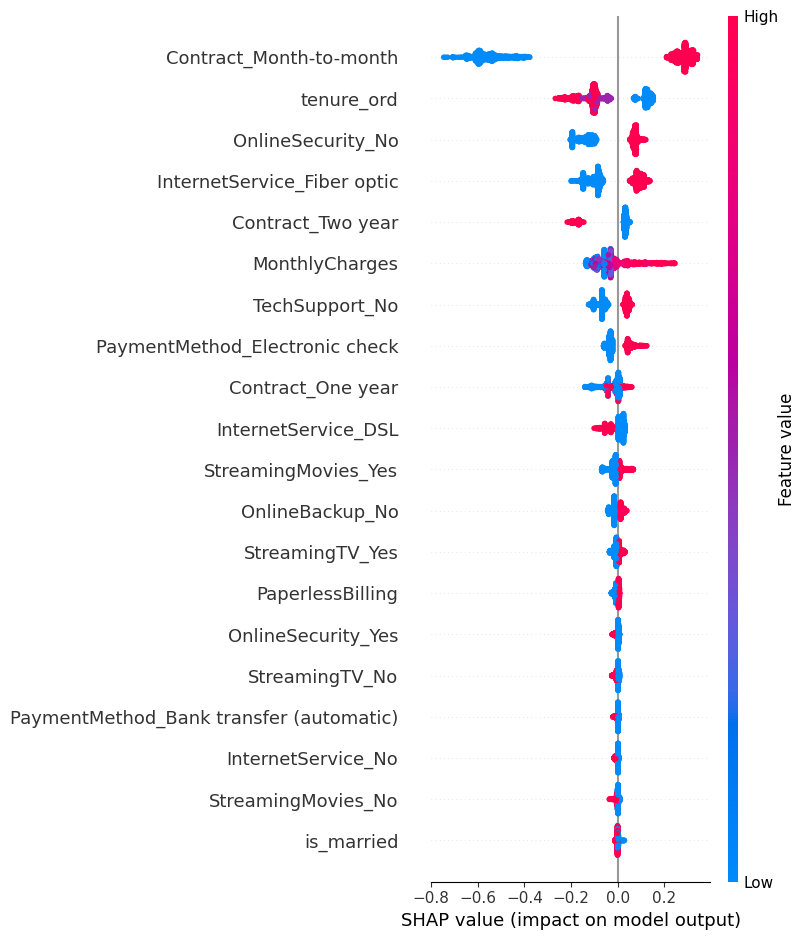

In [14]:
shap.summary_plot(shap_values, X_test)


In [ ]:
# 6) (Opsional) Tuning threshold pasca-model → kontrol FP vs FN
prec, rec, thr = precision_recall_curve(y_test, y_proba)
mask = rec >= 0.80  # contoh: target minimal recall 80%
if np.any(mask):
    i = np.argmax(prec[mask])     # presisi tertinggi dengan recall ≥ target
    thr_opt = thr[mask][i]
    y_pred_thr = (y_proba >= thr_opt).astype(int)
    print(f"\nThreshold optimal (recall>=0.80): {thr_opt:.4f}")
    print(confusion_matrix(y_test, y_pred_thr))
    print(classification_report(y_test, y_pred_thr, target_names=["No Churn","Churn"]))